<a href="https://colab.research.google.com/github/SolFreire/OverfittingMitigationExperiments/blob/main/OptimizersTryoutToReduceOverfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchsummary import summary
import sklearn.datasets
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt


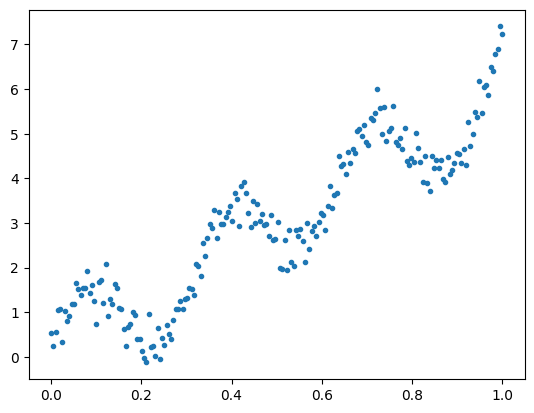

(200,)


In [3]:
np.random.seed(0)
X = np.arange(0,20,0.1)
Y= np.sin(X) + 0.3*np.random.randn(X.shape[0]) + 0.3*X

X = X / np.max(X)
plt.plot(X,Y,'.')
plt.show()
print(X.shape)

(30, 1)
(30, 1)
(140, 1)


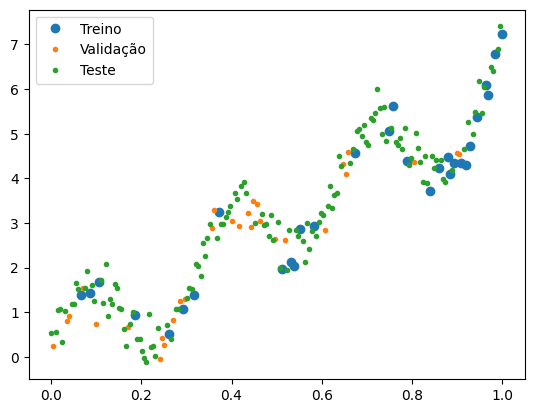

In [39]:
X = X.reshape((-1, 1))
Y = Y.reshape((-1, 1))

X_dev, X_test, Y_dev, Y_test = train_test_split(X, Y, test_size=0.7, random_state = 42)

X_train, X_val, Y_train, Y_val = train_test_split(X_dev,Y_dev, test_size=0.5,random_state = 42)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

plt.plot(X_train, Y_train, 'o', label='Treino')
plt.plot(X_val, Y_val, '.', label='Validação')
plt.plot(X_test, Y_test, '.', label='Teste')
plt.legend()
plt.show()

In [40]:
x_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(Y_train)

x_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(Y_val)

x_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(Y_test)

In [11]:
class MLP(nn.Module):
  def __init__(self, input_dim, output_dim):
    super(MLP,self).__init__()
    self.layers = nn.Sequential(
        nn.Linear(input_dim,512),
        nn.Tanh(),
        nn.Linear(512,256),
        nn.Tanh(),
        nn.Linear(256,128),
        nn.Tanh(),
        nn.Linear(128,64),
        nn.Tanh(),
        nn.Linear(64,output_dim),
    )
  def forward(self,x):
    return self.layers(x)

# The split and model architecture are intentionally configured to induce overfitting.



In [12]:
input_dim = 1
output_dim =1

model = MLP(input_dim, output_dim)
print(model)
summary(model,(1,1))

MLP(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=512, bias=True)
    (1): Tanh()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 1, 512]           1,024
              Tanh-2               [-1, 1, 512]               0
            Linear-3               [-1, 1, 256]         131,328
              Tanh-4               [-1, 1, 256]               0
            Linear-5               [-1, 1, 128]          32,896
              Tanh-6               [-1, 1, 128]               0
            Linear-7                [-1, 1, 64]           8,256
              Tanh-8

In [14]:
eta = 0.02
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=eta)

In [20]:
def train_network(model, optimizer, loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses, val_losses):
  for epoch in range(num_epochs):
    optimizer.zero_grad()

    output_train = model(x_train)

    loss_train = loss_function(output_train, y_train)

    loss_train.backward()
    optimizer.step()

    output_val = model(x_val)
    loss_val = loss_function(output_val, y_val)

    train_losses[epoch]=loss_train.item()
    val_losses[epoch] = loss_val.item()

    if(epoch +1)%500 == 0:
      print(f"Epoch{epoch+1}/{num_epochs}, Train Error: {loss_train.item():.4f}, Validation Error:  {loss_val.item():.4f} ")


In [41]:
num_epochs = 10000
train_losses = np.zeros(num_epochs)
val_losses = np.zeros(num_epochs)

train_network(model,optimizer,loss_function, x_train, y_train, x_val, y_val, num_epochs, train_losses, val_losses)

Epoch500/10000, Train Error: 0.0736, Validation Error:  0.1931 
Epoch1000/10000, Train Error: 0.0649, Validation Error:  0.2073 
Epoch1500/10000, Train Error: 0.0613, Validation Error:  0.2159 
Epoch2000/10000, Train Error: 0.0584, Validation Error:  0.2222 
Epoch2500/10000, Train Error: 0.0560, Validation Error:  0.2274 
Epoch3000/10000, Train Error: 0.0539, Validation Error:  0.2317 
Epoch3500/10000, Train Error: 0.0520, Validation Error:  0.2354 
Epoch4000/10000, Train Error: 0.0504, Validation Error:  0.2385 
Epoch4500/10000, Train Error: 0.0488, Validation Error:  0.2415 
Epoch5000/10000, Train Error: 0.0474, Validation Error:  0.2443 
Epoch5500/10000, Train Error: 0.0461, Validation Error:  0.2473 
Epoch6000/10000, Train Error: 0.0449, Validation Error:  0.2502 
Epoch6500/10000, Train Error: 0.0436, Validation Error:  0.2546 
Epoch7000/10000, Train Error: 0.0428, Validation Error:  0.2576 
Epoch7500/10000, Train Error: 0.0508, Validation Error:  0.2636 
Epoch8000/10000, Train Err

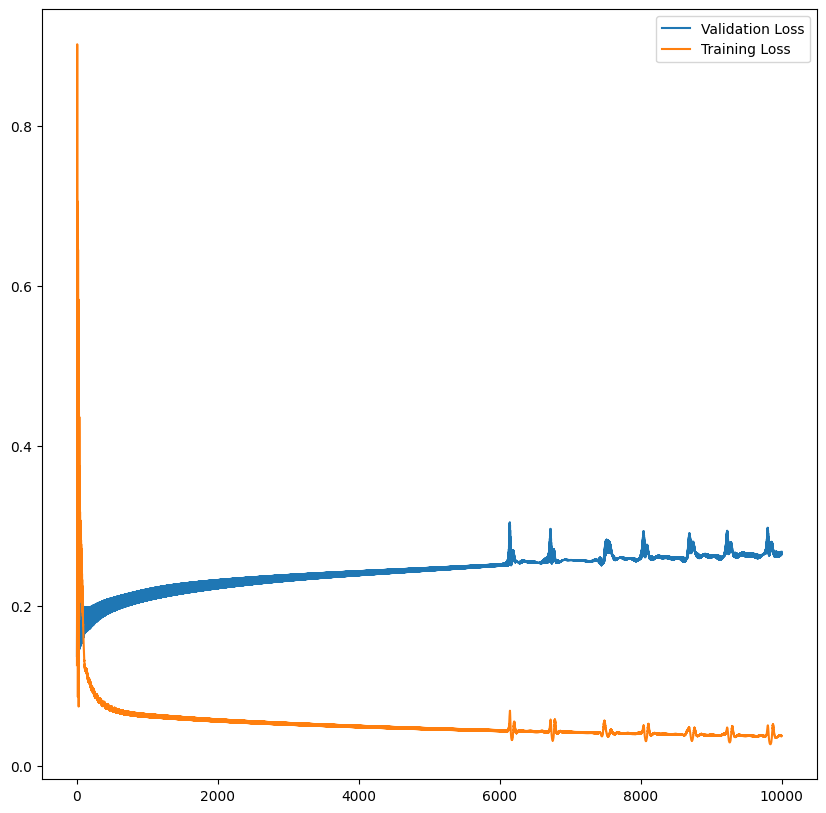

In [42]:
# Training is converging while validation error remains high
plt.figure(figsize=(10,10))
plt.plot(val_losses, label='Validation Loss')
plt.plot(train_losses, label='Training Loss')
plt.legend()
plt.show()

In [46]:
predictions_train=[]
predictions_train=[]
predictions_test=[]

with torch.no_grad():
  predictions_train = model(x_train)
  predictions_val = model(x_val)
  predictions_test = model(x_test)

error_train = loss_function(predictions_train, y_train)
error_val = loss_function(predictions_val, y_val)
error_test = loss_function(predictions_test, y_test)

print(f"Training Error: {error_train.item():.4f}")
print(f"Validation Error: {error_val.item():.4f}")
print(f"Test Error: {error_test.item():.4f}")

Training Error: 0.0371
Validation Error: 0.2678
Test Error: 0.2738


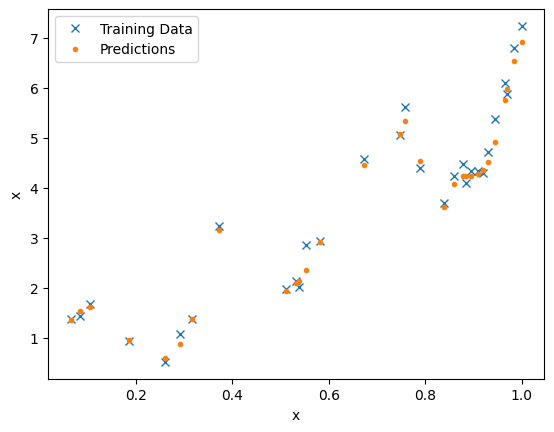

In [90]:
plt.plot(x_train,y_train, 'x', label="Training Data")
plt.plot(x_train, predictions_train,'.', label="Predictions")
plt.xlabel('x')
plt.ylabel('x')
plt.legend()
plt.show()

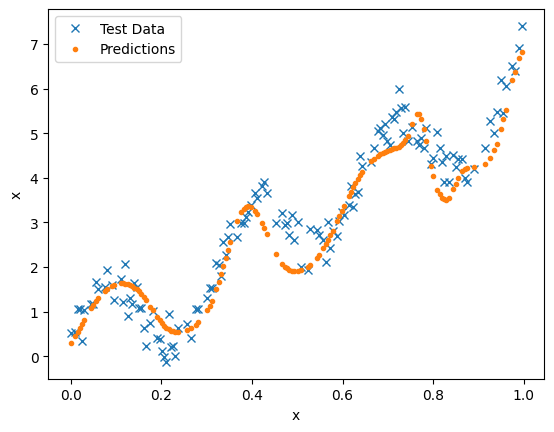

In [89]:
plt.plot(x_test,y_test, 'x', label="Test Data")
plt.plot(x_test, predictions_test,'.', label="Predictions")
plt.xlabel('x')
plt.ylabel('x')
plt.legend()
plt.show()

In [65]:
# The graph shows some signs of overfitting

input_dim = 1
output_dim = 1

model2 = MLP(input_dim, output_dim)

eta = 0.02
mom = 0.6
loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(model2.parameters(), lr=eta, momentum=mom)


In [57]:
num_epochs = 10000
train_losses2 = np.zeros(num_epochs)
val_losses2 = np.zeros(num_epochs)

train_network(model2, optimizer,loss_function,x_train,y_train, x_val, y_val, num_epochs,train_losses2, val_losses2)

Epoch500/10000, Train Error: 1.1734, Validation Error:  0.9541 
Epoch1000/10000, Train Error: 0.2474, Validation Error:  0.8514 
Epoch1500/10000, Train Error: 0.1726, Validation Error:  0.7859 
Epoch2000/10000, Train Error: 0.1303, Validation Error:  0.4800 
Epoch2500/10000, Train Error: 0.0567, Validation Error:  0.3391 
Epoch3000/10000, Train Error: 0.0351, Validation Error:  0.3504 
Epoch3500/10000, Train Error: 0.0413, Validation Error:  0.3348 
Epoch4000/10000, Train Error: 0.0320, Validation Error:  0.3333 
Epoch4500/10000, Train Error: 0.0336, Validation Error:  0.3230 
Epoch5000/10000, Train Error: 0.0416, Validation Error:  0.3352 
Epoch5500/10000, Train Error: 0.0307, Validation Error:  0.2941 
Epoch6000/10000, Train Error: 0.0289, Validation Error:  0.2956 
Epoch6500/10000, Train Error: 0.0356, Validation Error:  0.3152 
Epoch7000/10000, Train Error: 0.0231, Validation Error:  0.2713 
Epoch7500/10000, Train Error: 0.0190, Validation Error:  0.2630 
Epoch8000/10000, Train Err

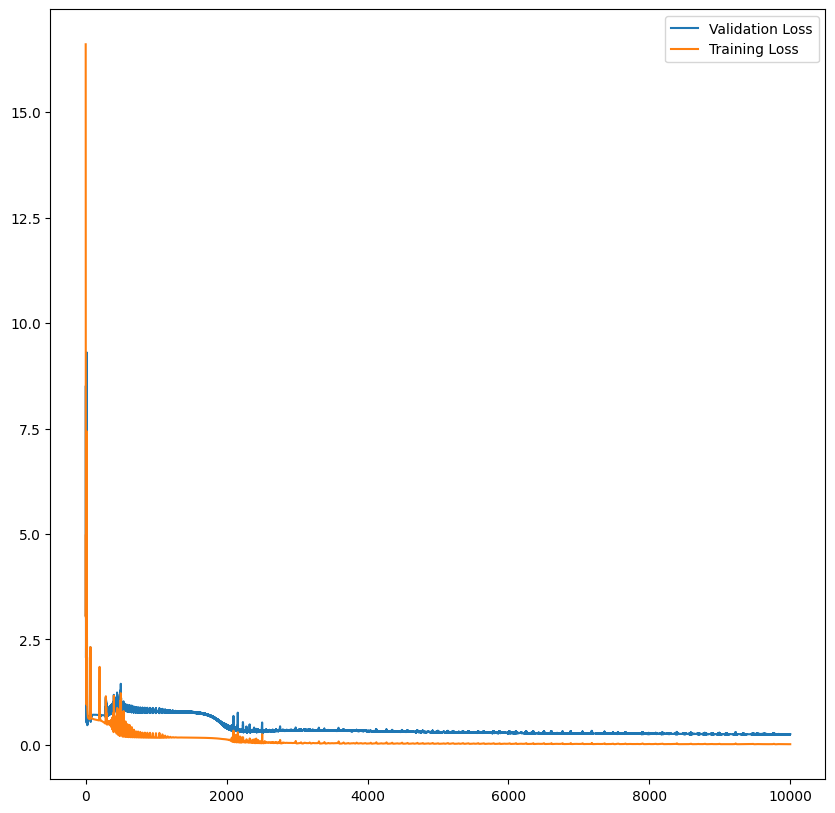

In [58]:
plt.figure(figsize=(10,10))
plt.plot(val_losses2, label='Validation Loss')
plt.plot(train_losses2, label='Training Loss')
plt.legend()
plt.show()

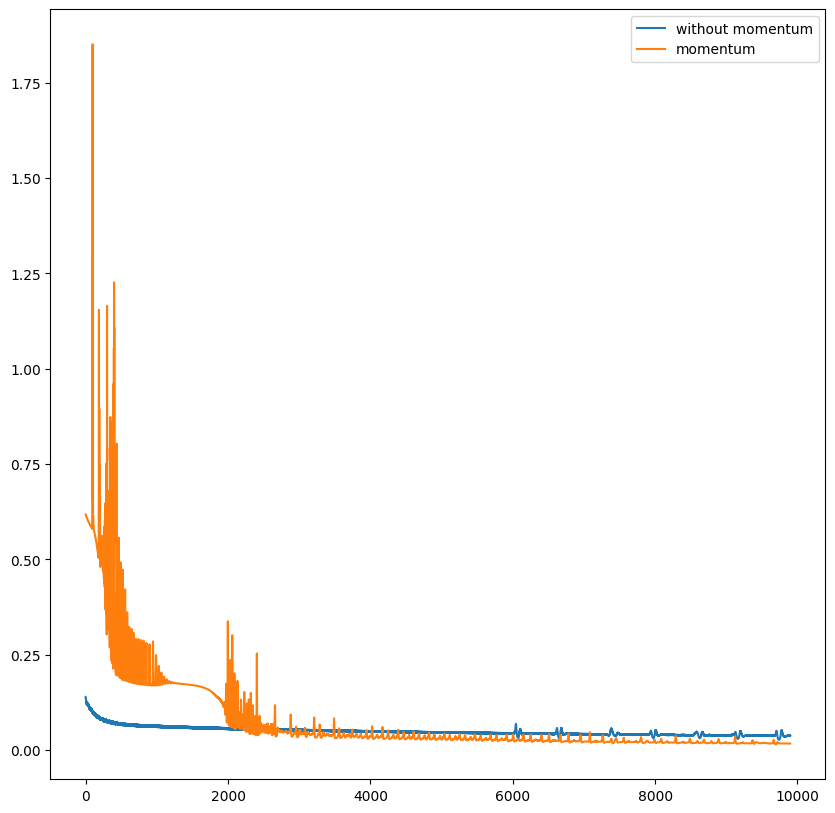

In [60]:
plt.figure(figsize=(10,10))
plt.plot(train_losses[100:], label='without momentum')
plt.plot(train_losses2[100:], label='momentum')
plt.legend()
plt.show()

In [61]:
predictions_train2=[]
predictions_train2=[]
predictions_test2=[]

with torch.no_grad():
  predictions_train2 = model2(x_train)
  predictions_val2 = model2(x_val)
  predictions_test2 = model2(x_test)

error_train2 = loss_function(predictions_train2, y_train)
error_val2 = loss_function(predictions_val2, y_val)
error_test2 = loss_function(predictions_test2, y_test)

print(f"Training Error: {error_train2.item():.4f}")
print(f"Validation Error: {error_val2.item():.4f}")
print(f"Test Error: {error_test2.item():.4f}")

Training Error: 0.0173
Validation Error: 0.2549
Test Error: 0.2460


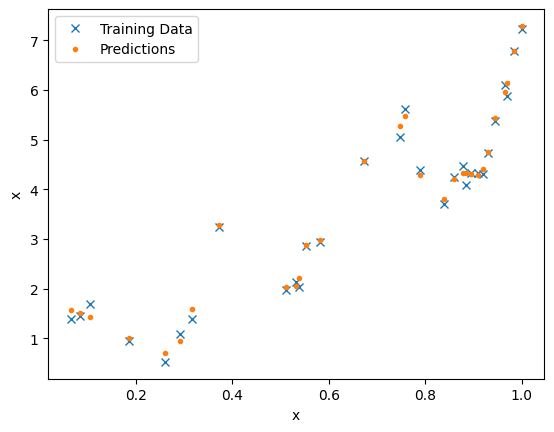

In [88]:
plt.plot(x_train,y_train, 'x', label="Training Data")
plt.plot(x_train, predictions_train2,'.', label="Predictions")
plt.xlabel('x')
plt.ylabel('x')
plt.legend()
plt.show()

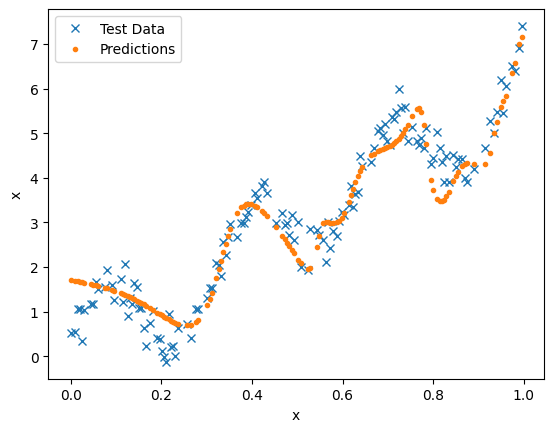

In [87]:
plt.plot(x_test,y_test, 'x', label="Test Data")
plt.plot(x_test, predictions_test2,'.', label="Predictions")
plt.xlabel('x')
plt.ylabel('x')
plt.legend()
plt.show()
#The performance improvement obtained by adding only the momentum term was very small.


In [66]:
input_dim = 1
output_dim = 1

model3 = MLP(input_dim, output_dim)

In [67]:
eta = 0.001
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model3.parameters(), lr=eta)

In [68]:
num_epochs = 10000
train_losses3 = np.zeros(num_epochs)
val_losses3 = np.zeros(num_epochs)

train_network(model3, optimizer,loss_function,x_train,y_train, x_val, y_val, num_epochs,train_losses3, val_losses3)

Epoch500/10000, Train Error: 0.0334, Validation Error:  0.3235 
Epoch1000/10000, Train Error: 0.0197, Validation Error:  0.2577 
Epoch1500/10000, Train Error: 0.0094, Validation Error:  0.1632 
Epoch2000/10000, Train Error: 0.0066, Validation Error:  0.1522 
Epoch2500/10000, Train Error: 0.0061, Validation Error:  0.1749 
Epoch3000/10000, Train Error: 0.0092, Validation Error:  0.2151 
Epoch3500/10000, Train Error: 0.0048, Validation Error:  0.2324 
Epoch4000/10000, Train Error: 0.0038, Validation Error:  0.2623 
Epoch4500/10000, Train Error: 0.0027, Validation Error:  0.2797 
Epoch5000/10000, Train Error: 0.0028, Validation Error:  0.3017 
Epoch5500/10000, Train Error: 0.0017, Validation Error:  0.2983 
Epoch6000/10000, Train Error: 0.0015, Validation Error:  0.3049 
Epoch6500/10000, Train Error: 0.0014, Validation Error:  0.3111 
Epoch7000/10000, Train Error: 0.0013, Validation Error:  0.3080 
Epoch7500/10000, Train Error: 0.0009, Validation Error:  0.3060 
Epoch8000/10000, Train Err

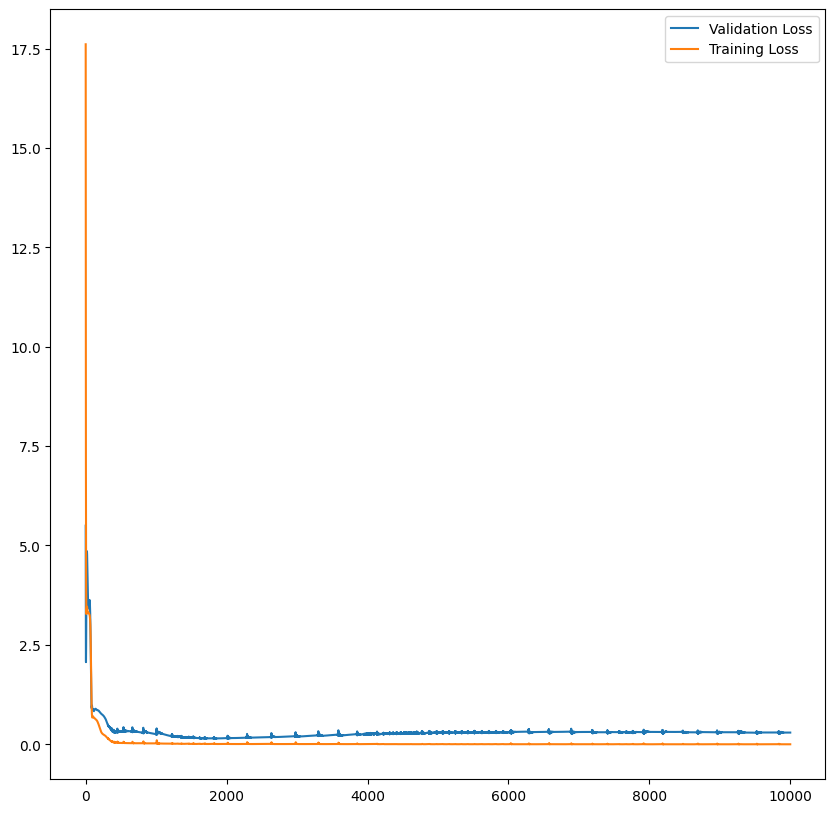

In [69]:
plt.figure(figsize=(10,10))
plt.plot(val_losses3, label='Validation Loss')
plt.plot(train_losses3, label='Training Loss')
plt.legend()
plt.show()

In [70]:
predictions_train3=[]
predictions_train3=[]
predictions_test3=[]

with torch.no_grad():
  predictions_train3 = model3(x_train)
  predictions_val3 = model3(x_val)
  predictions_test3 = model3(x_test)

error_train3 = loss_function(predictions_train3, y_train)
error_val3 = loss_function(predictions_val3, y_val)
error_test3 = loss_function(predictions_test3, y_test)

print(f"Training Error: {error_train3.item():.4f}")
print(f"Validation Error: {error_val3.item():.4f}")
print(f"Test Error: {error_test3.item():.4f}")

Training Error: 0.0000
Validation Error: 0.2945
Test Error: 0.2663


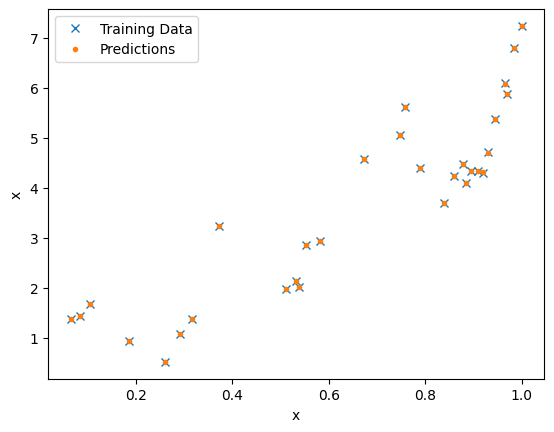

In [86]:
#Deep overfitting now, perfect interpolation of training data, even with lr initialized with a smaller value
plt.plot(x_train,y_train, 'x', label="Training Data")
plt.plot(x_train, predictions_train3,'.', label="Predictions")
plt.xlabel('x')
plt.ylabel('x')
plt.legend()
plt.show()

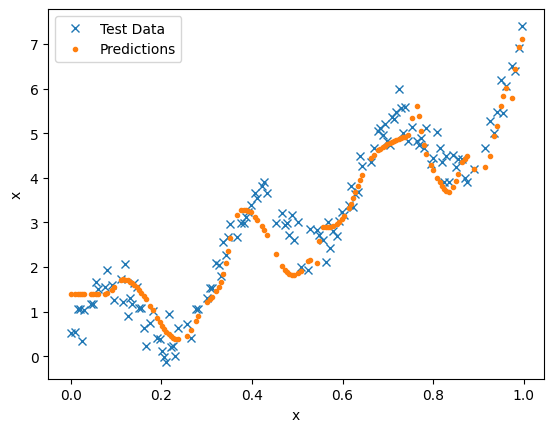

In [85]:
plt.plot(x_test,y_test, 'x', label="Test Data")
plt.plot(x_test, predictions_test3,'.', label="Predictions")
plt.xlabel('x')
plt.ylabel('x')
plt.legend()
plt.show()

In [73]:
input_dim = 1
output_dim = 1

model4 = MLP(input_dim, output_dim)

In [75]:
eta = 0.001
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model4.parameters(), lr=eta, weight_decay=0.005)

In [77]:
num_epochs = 10000
train_losses4 = np.zeros(num_epochs)
val_losses4 = np.zeros(num_epochs)

train_network(model4, optimizer,loss_function,x_train,y_train, x_val, y_val, num_epochs,train_losses4, val_losses4)

Epoch500/10000, Train Error: 0.0488, Validation Error:  0.2842 
Epoch1000/10000, Train Error: 0.0491, Validation Error:  0.2762 
Epoch1500/10000, Train Error: 0.0494, Validation Error:  0.2660 
Epoch2000/10000, Train Error: 0.0494, Validation Error:  0.2546 
Epoch2500/10000, Train Error: 0.0494, Validation Error:  0.2442 
Epoch3000/10000, Train Error: 0.0492, Validation Error:  0.2350 
Epoch3500/10000, Train Error: 0.0500, Validation Error:  0.2293 
Epoch4000/10000, Train Error: 0.0490, Validation Error:  0.2206 
Epoch4500/10000, Train Error: 0.0490, Validation Error:  0.2145 
Epoch5000/10000, Train Error: 0.0488, Validation Error:  0.2095 
Epoch5500/10000, Train Error: 0.0491, Validation Error:  0.2034 
Epoch6000/10000, Train Error: 0.0491, Validation Error:  0.2011 
Epoch6500/10000, Train Error: 0.0487, Validation Error:  0.1980 
Epoch7000/10000, Train Error: 0.0502, Validation Error:  0.1986 
Epoch7500/10000, Train Error: 0.0491, Validation Error:  0.1996 
Epoch8000/10000, Train Err

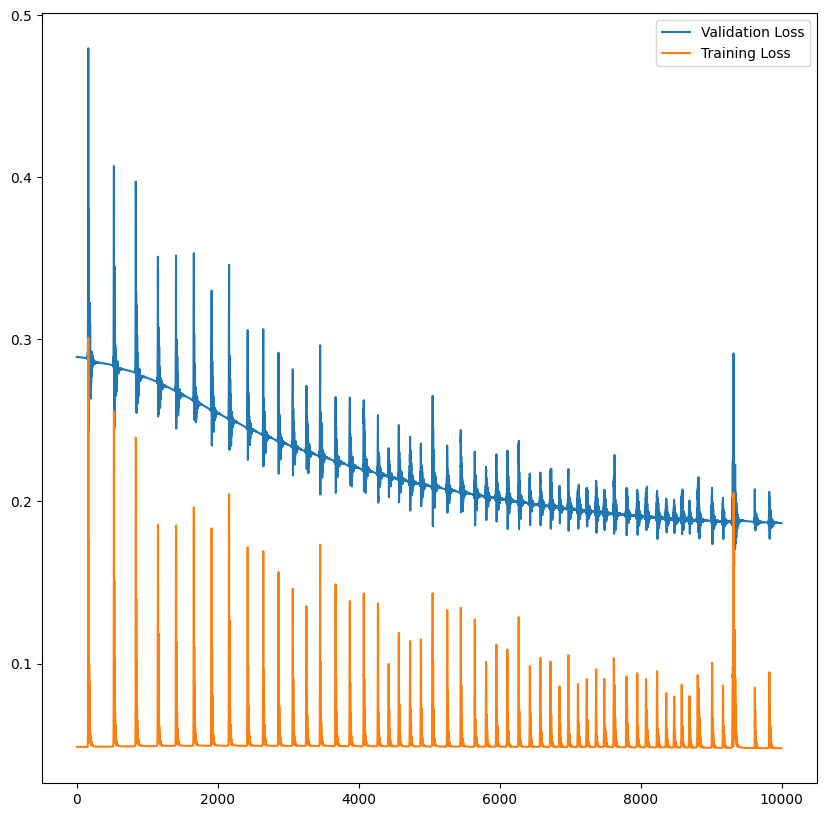

In [78]:
plt.figure(figsize=(10,10))
plt.plot(val_losses4, label='Validation Loss')
plt.plot(train_losses4, label='Training Loss')
plt.legend()
plt.show()

In [79]:
predictions_train4=[]
predictions_train4=[]
predictions_test4=[]

with torch.no_grad():
  predictions_train4 = model4(x_train)
  predictions_val4 = model4(x_val)
  predictions_test4 = model4(x_test)

error_train4 = loss_function(predictions_train4, y_train)
error_val4 = loss_function(predictions_val4, y_val)
error_test4 = loss_function(predictions_test4, y_test)

print(f"Training Error: {error_train4.item():.4f}")
print(f"Validation Error: {error_val4.item():.4f}")
print(f"Test Error: {error_test4.item():.4f}")

Training Error: 0.0477
Validation Error: 0.1867
Test Error: 0.1455


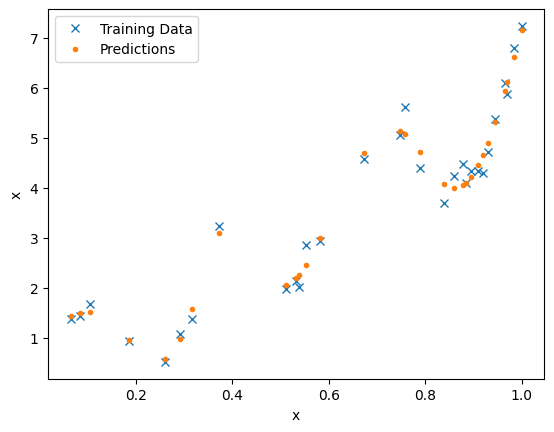

In [84]:
#L2 regularization with a coefficient of 0.005 helped reduce overfitting and improved the model’s fit.

plt.plot(x_train,y_train, 'x', label="Training Data")
plt.plot(x_train, predictions_train4,'.', label="Predictions")
plt.xlabel('x')
plt.ylabel('x')
plt.legend()
plt.show()

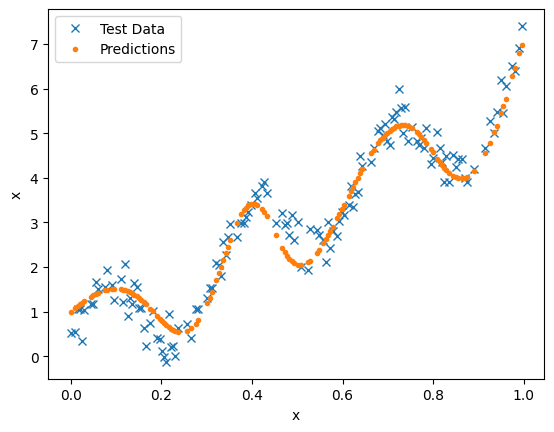

In [83]:
plt.plot(x_test,y_test, 'x', label="Test Data")
plt.plot(x_test, predictions_test4,'.', label="Predictions")
plt.xlabel('x')
plt.ylabel('x')
plt.legend()
plt.show()

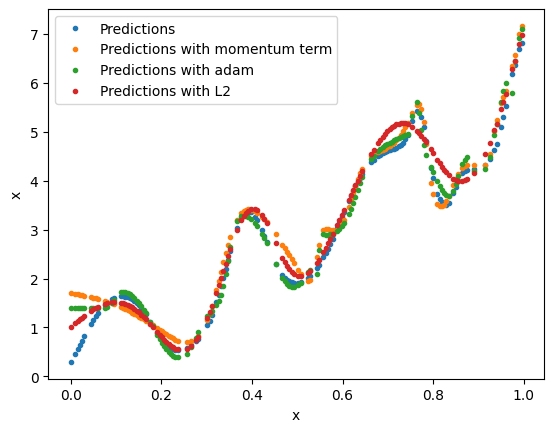

In [96]:

plt.plot(x_test, predictions_test,'.', label="Predictions")
plt.plot(x_test, predictions_test2,'.', label="Predictions with momentum term")
plt.plot(x_test, predictions_test3,'.', label="Predictions with adam")
plt.plot(x_test, predictions_test4,'.', label="Predictions with L2")
plt.xlabel('x')
plt.ylabel('x')
plt.legend()
plt.show()